# 02 — YOLO26 Baseline Fine-Tune (Detection)

**Phase 1 (Exploration & Learning)**, per [`plan.md`](../plan.md) and [`constitution.md`](../constitution.md) Principle II — run on **Google Colab** (T4 GPU), not locally.

**Goal:** sanity-check the `ultralytics` YOLO26 API end-to-end on ChickenDet — fine-tune a small pretrained checkpoint, confirm the train/val loop runs, and inspect the prediction output format (`results[0].boxes`). Informs the productionized wrapper in `src/poultry_monitoring/detection/yolo.py` (Phase 2). Not a tuned, benchmark-quality result.

**Out of scope:** full-dataset training/tuning (Phase 2), MLflow logging (local-only store, unreachable from Colab), segmentation, augmentation (Phase 4), DETR (separate notebook).

---

Learnings go in the **Notes** section at the bottom — that's the actual input to Phase 2.

## Setup

Runs on **Colab** (free T4) or the repo's local `uv`-managed `.venv` (verified CUDA GPU) — the
cell below detects which and adapts installs/paths accordingly. See `CLAUDE.md` § Environment.

In [ ]:
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print(f"Environment: {'Colab' if IN_COLAB else 'local (.venv)'}")

if IN_COLAB:
    # Runtime > Change runtime type > T4 GPU
    get_ipython().system("pip install ultralytics torchinfo")
# Locally, deps come from `uv sync --extra dev` (CLAUDE.md § Commands) — nothing to install here.

In [2]:
if IN_COLAB:
    from google.colab import drive

    drive.mount("/content/drive")

## Point at ChickenDet

On Colab, reuses the same Drive-mounted copy as [`01_explore_chickenverse.ipynb`](01_explore_chickenverse.ipynb).
Locally, uses the repo's own `data/` (gitignored — see `CLAUDE.md` § Gitignore Reminders); run
[`01_explore_chickenverse.ipynb`](01_explore_chickenverse.ipynb)'s download step first if it's empty.

In [4]:
if IN_COLAB:
    DATA_DIR = Path("/content/drive/MyDrive/Colab Notebooks/poultry_monitoring/data/ChickenDet")
else:
    DATA_DIR = Path.cwd().parent / "data" / "ChickenDet"  # repo-local, run from notebooks/

assert DATA_DIR.exists(), f"Dataset not found at {DATA_DIR}"

# Show Data directory selected
print(f"Data directory: {DATA_DIR}")

Data directory: c:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet


## Load libraries

In [18]:
# Standard library
import json
import random
import shutil
from pathlib import Path

# Third-party
import matplotlib.pyplot as plt
import pandas as pd
import torch
import yaml
from PIL import Image, ImageOps
from torchinfo import summary
from ultralytics import YOLO
from ultralytics.data.converter import convert_coco

# make plots appear inline in the notebook
%matplotlib inline

In [6]:
import ultralytics

print(f"ultralytics: {ultralytics.__version__}")
print(f"torch:       {torch.__version__} (built for CUDA {torch.version.cuda})")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
elif IN_COLAB:
    raise RuntimeError(
        "No GPU attached -- Runtime > Change runtime type > T4 GPU, then restart and re-run."
    )
else:
    raise RuntimeError(
        'No GPU visible in the local .venv -- check `uv run python -c "import torch; '
        'print(torch.cuda.is_available())"` and the CUDA wheel index in pyproject.toml '
        "(constitution Principle IX) before re-running."
    )

ultralytics: 8.4.117
torch:       2.6.0+cu124 (built for CUDA 12.4)
CUDA available: True
GPU: NVIDIA GeForce RTX 2060 SUPER


## Configuration

All paths, hyperparameters, and thresholds used below. `QUICK_SANITY_MODE=True` runs a small
subset for a few epochs (this notebook's actual scope); `False` runs the fuller pass.

In [7]:
ANNOTATIONS_DIR = DATA_DIR / "annotations"
YOLO_YAML_PATH = DATA_DIR / "chickendet.yaml"

SEED = 42
random.seed(SEED)

MODEL_NAME = "yolo26n"  # smallest variant — sanity-check, not a size comparison
CLASS_NAMES = {0: "Chicken"}  # single class, confirmed in 01_explore_chickenverse.ipynb

QUICK_SANITY_MODE = True

if QUICK_SANITY_MODE:
    TRAIN_FRACTION = 0.1
    EPOCHS = 50
    PATIENCE = 5
else:
    TRAIN_FRACTION = 1.0
    EPOCHS = 100
    PATIENCE = 10

# --- Training hyperparameters -----------------------------------------------
# Ultralytics' own fine-tuning guidance for small/limited datasets: freeze most of the
# backbone and drop the LR well below from-scratch training, so the pretrained COCO
# features aren't wrecked by a few noisy gradient steps on a much smaller dataset.
IMG_SIZE = 640
BATCH_SIZE = -1  # fill the GPU (T4 16GB VRAM is the binding constraint)
LR0 = 0.001  # low LR — fine-tuning a pretrained checkpoint, not training from scratch
FREEZE_LAYERS = 10  # freeze the backbone stem; only the neck/head adapt to chickens

# Mosaic stitches 4 training images into one, exposing the model to more object scales/
# contexts per batch and effectively acting as a strong augmentation for small datasets.
# It also produces unrealistic image statistics (odd object boundaries, scale mismatches),
# so `close_mosaic` disables it for the final N epochs — letting the model fine-tune on
# real, undistorted images right before it's evaluated on them.
MOSAIC = 0.5
CLOSE_MOSAIC = 10
RUN_NAME = f"{MODEL_NAME}-baseline"

# --- Inference thresholds -----------------------------------------------------
# CONF_THRESHOLD: minimum detection confidence to keep a box.
#   lower (toward 0.25) -> more boxes kept -> higher recall, more false positives/duplicates
#   higher (toward 0.45) -> fewer boxes kept -> higher precision, more missed birds
# 0.36 was picked from the F1 score curve on a prior run (the point where precision and
# recall trade off most favorably) — revisit per-model once Phase 2 runs a real sweep.
CONF_THRESHOLD = 0.36
IOU_THRESHOLD = 0.5  # NMS overlap threshold for de-duplicating boxes on the same bird

print(f"QUICK_SANITY_MODE={QUICK_SANITY_MODE} -> epochs={EPOCHS}, fraction={TRAIN_FRACTION}")

QUICK_SANITY_MODE=True -> epochs=20, fraction=0.1


## Convert COCO annotations → YOLO format

Ultralytics expects YOLO-format labels (`.txt` per image, normalized `class x_center y_center w h`),
not the COCO JSON `01_explore_chickenverse.ipynb` loaded with `pycocotools`. Ultralytics ships
[`convert_coco`](https://docs.ultralytics.com/reference/data/converter/) for this — two gotchas
it doesn't handle on its own:
- it silently **skips annotations with `iscrowd=1`** — ChickenDet ships some, so `fix_iscrowd_field` zeroes them out first.
- it writes one level deeper (`<save_dir>/labels/<json_stem>/`) than Ultralytics' training layout (`images/<split>` + `labels/<split>`) — `convert_coco_to_yolo_labels` moves the output into place.

Test split is skipped — held out for a later real evaluation.

In [8]:
def fix_iscrowd_field(coco_path: Path, assume_yes: bool = False) -> None:
    """Zero out every annotation's `iscrowd` field in a COCO JSON, in place.

    `convert_coco` silently drops any annotation with `iscrowd=1`. This is a destructive
    edit to the source JSON, so it's a no-op if already fixed, backs up to `.bak` before
    writing, and asks for confirmation unless `assume_yes=True`.
    """
    with coco_path.open("r") as f:
        coco = json.load(f)

    already_fixed = all(ann["iscrowd"] == 0 for ann in coco["annotations"])
    if already_fixed:
        print(f"{coco_path.name}: already iscrowd=0 everywhere, nothing to do.")
        return

    n_crowd = sum(ann["iscrowd"] != 0 for ann in coco["annotations"])
    print(f"{coco_path.name}: {n_crowd} annotation(s) have iscrowd != 0.")
    print("This will overwrite them to 0, in place. Re-download from Zenodo to undo.")
    if not assume_yes:
        confirmation = input("Proceed? (y/n): ")
        if confirmation.lower() != "y":
            print("Operation cancelled by user.")
            return

    backup_path = coco_path.with_suffix(coco_path.suffix + ".bak")
    if not backup_path.exists():
        shutil.copy2(coco_path, backup_path)
        print(f"Backed up original to {backup_path.name}")

    for ann in coco["annotations"]:
        ann["iscrowd"] = 0
    with coco_path.open("w") as f:
        json.dump(coco, f, indent=4)
    print(f"iscrowd set to 0 for all annotations in {coco_path.name}")

In [9]:
# Overwrite iscrowd on every split so convert_coco() below doesn't silently drop labels.
for split in ["Train", "Validation", "Test"]:
    fix_iscrowd_field(ANNOTATIONS_DIR / f"instances_{split}.json")

instances_Train.json: already iscrowd=0 everywhere, nothing to do.
instances_Validation.json: already iscrowd=0 everywhere, nothing to do.
instances_Test.json: already iscrowd=0 everywhere, nothing to do.


In [10]:
def convert_coco_to_yolo_labels(data_dir: Path, annotations_dir: Path, force: bool = False) -> Path:
    """Convert ChickenDet's COCO annotations to YOLO-format label files.

    Wraps `ultralytics.data.converter.convert_coco`, which never overwrites an existing
    `save_dir` and writes one level deeper than Ultralytics' training layout — this
    function skips re-conversion if `labels/` already exists (`force=True` to redo), and
    moves the output up a level to match `images/<split>` + `labels/<split>`.
    """
    labels_dir = data_dir / "labels"
    if labels_dir.exists():
        if not force:
            print(f"{labels_dir} already exists, skipping conversion (force=True to redo).")
            return labels_dir
        shutil.rmtree(labels_dir)

    scratch_dir = data_dir / "yolo_labels_tmp"
    if scratch_dir.exists():
        shutil.rmtree(scratch_dir)  # leftover from an interrupted previous run

    convert_coco(
        labels_dir=str(annotations_dir),  # source COCO JSON dir (confusing param name)
        save_dir=str(scratch_dir),
        use_segments=False,  # boxes only — this is the detection notebook
        use_keypoints=False,
        cls91to80=False,
    )
    shutil.move(str(scratch_dir / "labels"), str(labels_dir))
    shutil.rmtree(scratch_dir)
    return labels_dir


labels_dir = convert_coco_to_yolo_labels(DATA_DIR, ANNOTATIONS_DIR)
print(f"YOLO labels at: {labels_dir}")

c:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\labels already exists, skipping conversion (force=True to redo).
YOLO labels at: c:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\labels


## Build the `data.yaml`

Ultralytics training is driven by a small YAML pointing at image/label dirs plus the class list.

In [11]:
def build_data_yaml(data_dir: Path, class_names: dict[int, str], yaml_path: Path) -> Path:
    """Write the Ultralytics dataset YAML (image dirs + class names) and return its path."""
    data_yaml = {
        "path": str(data_dir),
        "train": "images/Train",
        "val": "images/Validation",
        "names": class_names,
    }
    with yaml_path.open("w") as f:
        yaml.safe_dump(data_yaml, f)
    return yaml_path


yaml_path = build_data_yaml(DATA_DIR, CLASS_NAMES, YOLO_YAML_PATH)
print(f"Wrote {yaml_path}")

Wrote c:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\chickendet.yaml


## Load pretrained checkpoint + fine-tune

Fine-tunes `MODEL_NAME` for `EPOCHS` epochs at `IMG_SIZE`, seeded via `SEED`. `QUICK_SANITY_MODE`
in `## Configuration` controls the subset/epoch count — flip it there, not here.

In [12]:
# Load the pretrained checkpoint (see ## Configuration above for MODEL_NAME)
model = YOLO(f"{MODEL_NAME}.pt")

# Visualize layers / param counts
summary(model.model)

Layer (type:depth-idx)                                       Param #
DetectionModel                                               --
├─Sequential: 1-1                                            --
│    └─Conv: 2-1                                             --
│    │    └─Conv2d: 3-1                                      (432)
│    │    └─BatchNorm2d: 3-2                                 (32)
│    │    └─SiLU: 3-3                                        --
│    └─Conv: 2-2                                             --
│    │    └─Conv2d: 3-4                                      (4,608)
│    │    └─BatchNorm2d: 3-5                                 (64)
│    │    └─SiLU: 3-6                                        --
│    └─C3k2: 2-3                                             --
│    │    └─Conv: 3-7                                        (1,088)
│    │    └─Conv: 3-8                                        (3,200)
│    │    └─ModuleList: 3-9                                  (2,352)
│    └─C

In [14]:
# The pretrained checkpoint's own original COCO training recipe, for reference
for key, value in model.ckpt["train_args"].items():
    print(f"{key}: {value}")

task: detect
mode: train
model: yolo26n-objv1-150.pt
data: /home/lq/codes/ultralytics/ultralytics/cfg/datasets/coco.yaml
epochs: 245
time: None
patience: 100
batch: 128
imgsz: 640
save: True
save_period: -1
cache: False
device: 5
workers: 8
project: tune-yolo26n-objv1-coco
name: train31
exist_ok: False
pretrained: True
optimizer: MuSGD
verbose: True
seed: 0
deterministic: True
single_cls: False
rect: False
cos_lr: False
close_mosaic: 10
resume: False
amp: True
fraction: 1.0
profile: False
freeze: None
multi_scale: 0.0
compile: False
overlap_mask: True
mask_ratio: 4
dropout: 0.0
val: True
split: val
save_json: True
conf: None
iou: 0.7
max_det: 300
half: False
dnn: False
plots: False
source: None
vid_stride: 1
stream_buffer: False
visualize: False
augment: False
agnostic_nms: False
classes: None
retina_masks: False
embed: None
show: False
save_frames: False
save_txt: False
save_conf: False
save_crop: False
show_labels: True
show_conf: True
show_boxes: True
line_width: None
format: torchs

In [15]:
# Ultralytics' suggested defaults as a starting point — a hyperparameter sweep is future work.

results = model.train(
    data=yaml_path,
    fraction=TRAIN_FRACTION,
    epochs=EPOCHS,
    patience=PATIENCE,
    imgsz=IMG_SIZE,
    batch=BATCH_SIZE,
    lr0=LR0,
    seed=SEED,
    project=str(DATA_DIR / "YOLO"),
    name=RUN_NAME,
    multi_scale=0,  # chickens vary a lot in apparent size — worth revisiting
    freeze=FREEZE_LAYERS,
    mosaic=MOSAIC,
    close_mosaic=CLOSE_MOSAIC,
    mixup=0.0,  # candidate for occlusion-heavy scenes
    copy_paste=0.0,  # segmentation-only in Ultralytics; relevant to the density
    # augmentation idea in plan.md's Future Work
    exist_ok=True,
    cache=False,  # True/"disk" speeds up training but costs RAM/disk
)

Ultralytics 8.4.117  Python-3.13.2 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=-1, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=20, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\chickendet.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=20, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=0.1, freeze=10, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=tra

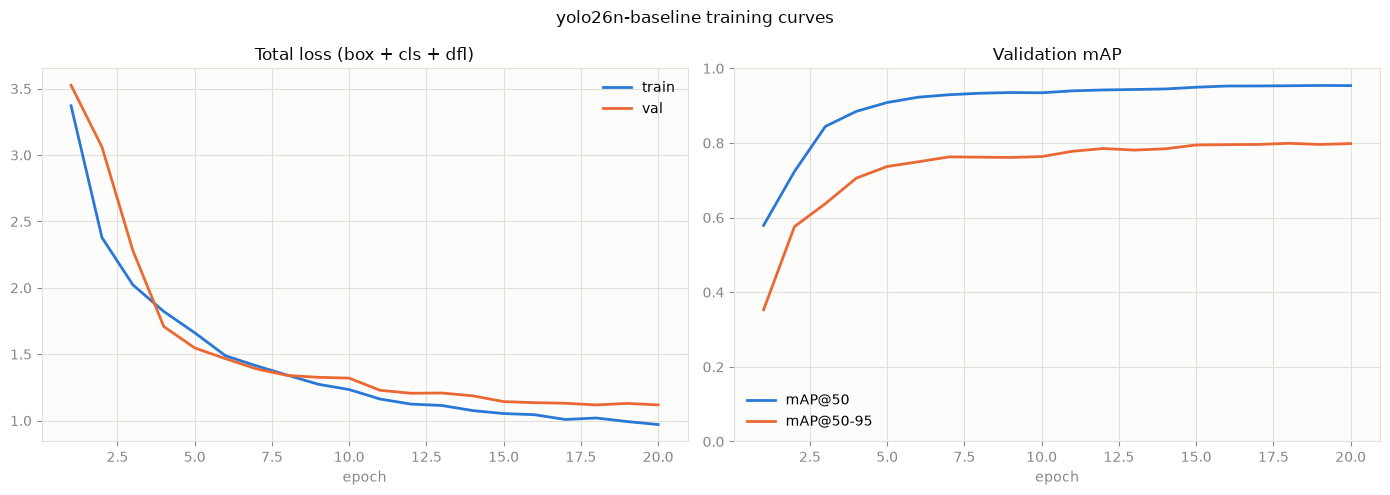

In [20]:
def plot_training_curves(results_csv_path: Path) -> None:
    """Plot train/val loss and validation mAP from an Ultralytics `results.csv`."""
    if not results_csv_path.exists():
        raise FileNotFoundError(f"Training history CSV not found: {results_csv_path}")

    history = pd.read_csv(results_csv_path)
    history.columns = [c.strip() for c in history.columns]

    if "epoch" not in history.columns:
        raise ValueError(f"{results_csv_path} does not have an `epoch` column; cannot plot curves.")

    # Prefer the YOLO26/Ultralytics loss names present in this repo's CSV export.
    train_loss_cols = [c for c in history.columns if c.startswith("train/") and c.endswith("_loss")]
    val_loss_cols = [c for c in history.columns if c.startswith("val/") and c.endswith("_loss")]

    if not train_loss_cols or not val_loss_cols:
        raise ValueError(
            f"{results_csv_path} contains no expected train/val loss columns "
            "for the requested plot."
        )

    train_loss = history[train_loss_cols].sum(axis=1)
    val_loss = history[val_loss_cols].sum(axis=1)

    BLUE, ORANGE = "#2a78d6", "#eb6834"
    GRID, MUTED, INK = "#e1e0d9", "#898781", "#0b0b0b"

    fig, (ax_loss, ax_map) = plt.subplots(1, 2, figsize=(14, 5))
    for ax in (ax_loss, ax_map):
        ax.set_facecolor("#fcfcfb")
        ax.grid(True, color=GRID, linewidth=0.8)
        ax.tick_params(colors=MUTED)
        for spine in ax.spines.values():
            spine.set_color(GRID)

    ax_loss.plot(history["epoch"], train_loss, color=BLUE, linewidth=2, label="train")
    ax_loss.plot(history["epoch"], val_loss, color=ORANGE, linewidth=2, label="val")
    ax_loss.set_title("Total loss (box + cls + dfl)", color=INK)
    ax_loss.set_xlabel("epoch", color=MUTED)
    ax_loss.legend(frameon=False)

    map50_candidates = ["metrics/mAP50(B)", "metrics/mAP50", "mAP50"]
    map95_candidates = ["metrics/mAP50-95(B)", "metrics/mAP50-95", "mAP50-95"]

    map50_col = next((c for c in map50_candidates if c in history.columns), None)
    map95_col = next((c for c in map95_candidates if c in history.columns), None)

    if map50_col is None or map95_col is None:
        raise ValueError(
            f"{results_csv_path} does not expose the expected YOLO validation mAP columns "
            "(mAP50 / mAP50-95)."
        )

    ax_map.plot(history["epoch"], history[map50_col], color=BLUE, linewidth=2, label="mAP@50")
    ax_map.plot(history["epoch"], history[map95_col], color=ORANGE, linewidth=2, label="mAP@50-95")
    ax_map.set_title("Validation mAP", color=INK)
    ax_map.set_xlabel("epoch", color=MUTED)
    ax_map.set_ylim(0, 1)
    ax_map.legend(frameon=False)

    fig.suptitle(f"{RUN_NAME} training curves", color=INK)
    fig.tight_layout()
    plt.show()


plot_training_curves(Path(results.save_dir) / "results.csv")

In [21]:
# Reload the *best* checkpoint, not whatever's left in `model` after the last epoch
best_weights_path = Path(results.save_dir) / "weights" / "best.pt"
model = YOLO(best_weights_path)
print(f"Reloaded best checkpoint: {best_weights_path}")

Reloaded best checkpoint: C:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\YOLO\yolo26n-baseline\weights\best.pt


## Validate

Runs `model.val()` against the reloaded best checkpoint and prints `box.map50` / `box.map`
(mAP@50-95) plus precision/recall — confirming the metric names/shapes match what `metrics.py`
will need to log (`box_map50`, `box_map50_95` per `CLAUDE.md` § MLflow Conventions).

In [22]:
metrics = model.val(data=yaml_path)
print(f"box mAP50:    {metrics.box.map50:.4f}")
print(f"box mAP50-95: {metrics.box.map:.4f}")
print(f"precision:    {metrics.box.mp:.4f}")
print(f"recall:       {metrics.box.mr:.4f}")

Ultralytics 8.4.117  Python-3.13.2 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 2060 SUPER, 8192MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.3 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 439.9105.4 MB/s, size: 889.0 KB)
val: Scanning C:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\labels\Validation.cache... 1067 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1067/1067 223.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 67/67 6.6it/s 10.1s0.1s
                   all       1067      24814       0.94      0.878      0.953      0.799
Speed: 1.8ms preprocess, 2.7ms inference, 0.0ms loss, 0.3ms postprocess per image
Results saved to C:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\runs\detect\val
box mAP50:    0.9533
box mAP50-95: 0.7992
precision:    0.9396
recall:       0.8776


## Visualize predictions vs. ground truth

Runs inference on one validation image and plots prediction vs. ground-truth boxes side by side.
A second, optional cell repeats the prediction on an autocontrast-enhanced version of the same
image, to eyeball whether that preprocessing changes what gets detected.

In [ ]:
def select_random_image(image_dir: Path, seed: int | None = None) -> Path:
    """Pick a random image from `image_dir` (reproducible if `seed` is given)."""
    rng = random.Random(seed)
    image_paths = list(image_dir.glob("*.jpg"))
    if not image_paths:
        raise FileNotFoundError(f"No .jpg images found in {image_dir}")
    return rng.choice(image_paths)


def load_yolo_label_boxes(
    label_path: Path, image_size: tuple[int, int]
) -> list[tuple[float, float, float, float]]:
    """Read a YOLO-format label file and return boxes as pixel (x1, y1, w, h)."""
    if not label_path.exists():
        return []
    w, h = image_size
    boxes = []
    for line in label_path.read_text().splitlines():
        _cls, x_c, y_c, bw, bh = map(float, line.split())
        x1 = (x_c - bw / 2) * w
        y1 = (y_c - bh / 2) * h
        boxes.append((x1, y1, bw * w, bh * h))
    return boxes


def plot_prediction_vs_ground_truth(image_path: Path, prediction, label_path: Path) -> None:
    """Side-by-side comparison: model prediction (left) vs. ground truth (right)."""
    GT_COLOR = "#1baf7a"  # categorical slot 3

    with Image.open(image_path) as img:
        w, h = img.size
        fig, (ax_pred, ax_gt) = plt.subplots(1, 2, figsize=(20, 10))

        pred_rgb = prediction.plot()[..., ::-1]  # BGR -> RGB
        ax_pred.imshow(pred_rgb)
        ax_pred.set_title(f"Prediction ({len(prediction.boxes)} boxes, conf>={CONF_THRESHOLD})")
        ax_pred.axis("off")

        ax_gt.imshow(img)
        gt_boxes = load_yolo_label_boxes(label_path, (w, h))
        for x1, y1, bw, bh in gt_boxes:
            ax_gt.add_patch(
                plt.Rectangle((x1, y1), bw, bh, fill=False, color=GT_COLOR, linewidth=2)
            )
        ax_gt.set_title(f"Ground truth ({len(gt_boxes)} boxes)")
        ax_gt.axis("off")

        fig.tight_layout()
        plt.show()

Image:  c:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\images\Validation\fCam13.20230209_070002_0014.jpg
Labels: c:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\labels\Validation\fCam13.20230209_070002_0014.txt

image 1/1 c:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\images\Validation\fCam13.20230209_070002_0014.jpg: 416x640 27 Chickens, 124.8ms
Speed: 4.7ms preprocess, 124.8ms inference, 0.7ms postprocess per image at shape (1, 3, 416, 640)
Original image shape: (900, 1400)
Number of boxes: 27
preprocess: 4.7 ms
inference: 124.8 ms
postprocess: 0.7 ms


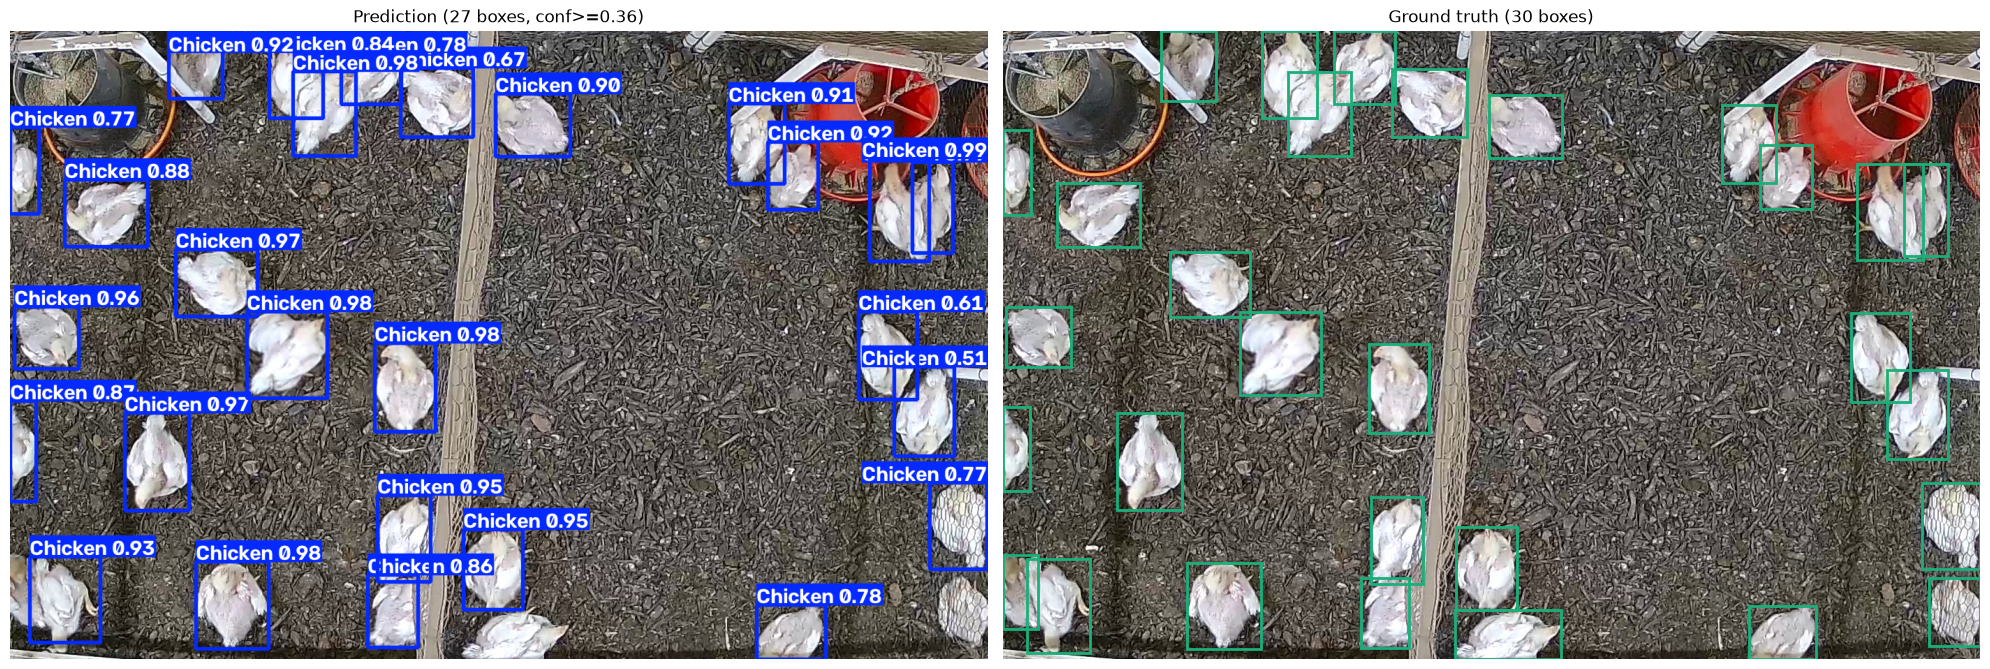

In [26]:
val_image_dir = DATA_DIR / "images" / "Validation"
val_label_dir = DATA_DIR / "labels" / "Validation"

image_path = select_random_image(val_image_dir, seed=None)
label_path = val_label_dir / image_path.with_suffix(".txt").name
print(f"Image:  {image_path}")
print(f"Labels: {label_path}")

[prediction] = model.predict(source=str(image_path), conf=CONF_THRESHOLD, iou=IOU_THRESHOLD)
print(f"Original image shape: {prediction.orig_shape}")
print(f"Number of boxes: {len(prediction.boxes)}")
for key, value in prediction.speed.items():
    print(f"{key}: {value:.1f} ms")

plot_prediction_vs_ground_truth(image_path, prediction, label_path)

In [ ]:
def compare_autocontrast_prediction(model: YOLO, image_path: Path, conf: float, iou: float) -> None:
    """Optional: does `ImageOps.autocontrast` change the detection count?"""
    with Image.open(image_path) as im:
        ac_img = ImageOps.autocontrast(im, cutoff=(10, 0))
        [ac_prediction] = model.predict(source=ac_img, conf=conf, iou=iou)

    print(
        f"Boxes with autocontrast: {len(ac_prediction.boxes)} "
        "(compare against the prediction above)"
    )
    for key, value in ac_prediction.speed.items():
        print(f"{key}: {value:.1f} ms")

    plt.figure(figsize=(10, 8))
    plt.imshow(Image.fromarray(ac_prediction.plot()[..., ::-1]))
    plt.title("Prediction on autocontrast-enhanced image")
    plt.axis("off")
    plt.show()


compare_autocontrast_prediction(model, image_path, CONF_THRESHOLD, IOU_THRESHOLD)

## Summary — handoff to Phase 2

Concrete numbers/paths for productionizing this into `src/poultry_monitoring/detection/yolo.py` (see `CLAUDE.md` § Package Layout and § MLflow Conventions).

In [28]:
print("=== Run summary ===")
print(f"Model:          {MODEL_NAME}")
print(f"Quick sanity:   {QUICK_SANITY_MODE} (fraction={TRAIN_FRACTION}, epochs={EPOCHS})")
print(f"Seed:           {SEED}")
print(f"Best weights:   {best_weights_path}")
print(f"box mAP50:      {metrics.box.map50:.4f}")
print(f"box mAP50-95:   {metrics.box.map:.4f}")

for split in ["Train", "Validation", "Test"]:
    n_images = len(list((DATA_DIR / "images" / split).glob("*.jpg")))
    print(f"{split} images: {n_images}")

print(
    "\nParams to log: "
    f"model_family='yolo26', variant='{MODEL_NAME}', "
    f"batch_size={BATCH_SIZE}, num_epochs={EPOCHS}, image_size={IMG_SIZE}, "
    f"augmentation_enabled=True, random_seed={SEED}"
)

=== Run summary ===
Model:          yolo26n
Quick sanity:   True (fraction=0.1, epochs=20)
Seed:           42
Best weights:   C:\Users\juane\Documents\Juanes\Proyectos\cv_portfolio\cv_portfolio\poultry_monitoring\data\ChickenDet\YOLO\yolo26n-baseline\weights\best.pt
box mAP50:      0.9533
box mAP50-95:   0.7992
Train images: 4494
Validation images: 1067
Test images: 250

Params to log: model_family='yolo26', variant='yolo26n', batch_size=-1, num_epochs=20, image_size=640, augmentation_enabled=True, random_seed=42


## Notes — what I learned

### Ultralytics API & conversion
- `convert_coco` silently skips annotations with `iscrowd=1` — must zero that field first or labels go missing.
- `convert_coco` never overwrites an existing `save_dir`; a stale target directory needs clearing before re-running.
- Ultralytics expects `images/` and `labels/` at the same level (`images/<split>`, `labels/<split>`) — `convert_coco`'s own output layout needs reorganizing to match.

### Training & hyperparameters
- **Fine-tuning on a small dataset (Ultralytics' own guidance)**: freeze most of the backbone (`freeze=10` here) and use a low `lr0` (`0.001`) — the pretrained COCO features are worth more than what a few epochs on a much smaller dataset could teach from scratch, and a high LR on a small dataset overfits/forgets fast.
- **Mosaic**: stitches 4 images into one training sample — cheap way to see more object scales/contexts per batch, effectively a strong augmentation when the dataset itself is small. But it makes for unrealistic image statistics (odd boundaries, scale mismatches), so `close_mosaic` turns it off for the final epochs to let the model settle on real image statistics before eval — turning it off too early loses the augmentation benefit, too late risks the model never adapting back to realistic inputs.
- `cache='disk'` (or `cache=True` if RAM allows) meaningfully speeds up iteration on Colab.

### Augmentation & density
- A lot of augmentation is on by default — worth making explicit for reproducibility once this moves to Phase 2/4.
- `copy_paste` is an interesting proxy for increasing chicken density; needs testing for detection (currently seg-only in Ultralytics).
- **Albumentations vs. DALI**: DALI's win is GPU-resident throughput — decode/augment never touches the CPU, which matters once training is data-loading-bound. But its augmentation op set is comparatively limited for target-aware transforms (occlusion-aware crops, copy-paste) — that's `albumentations` territory, and it's CPU-bound. Likely direction: DALI for the cheap/high-volume ops (resize, color jitter), `albumentations` for the bbox/mask-aware ones — worth benchmarking whether the CPU augmentation becomes the bottleneck before committing either way (Phase 5).

### Inference
- Dense clusters and background variation make chickens hard to separate; `conf`/`iou` trade recall against double-counting. Lower `conf` (~0.25) favors recall (fewer missed birds, more false positives/duplicates); higher (~0.45) favors precision. `CONF_THRESHOLD=0.36` was picked off the F1 curve on a prior run as a reasonable middle ground.
- `ImageOps.autocontrast` showed some promise for varied lighting — worth a proper test in Phase 4.

### Future work / open question
Whether the fuller run (`QUICK_SANITY_MODE=False`) is worth repeating here, or whether Phase 2's
productionized wrapper should just absorb these hyperparameters directly — leaning toward the
latter, since this notebook's job is API sanity-checking, not producing a reportable result.